In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv("../data/diabetic_data.csv")

# First look at the data
print("Dataset Shape: ", df.shape)
print("\nfirst 5 rows:")
df.head

Dataset Shape:  (101766, 50)

first 5 rows:


<bound method NDFrame.head of         encounter_id  patient_nbr             race  gender      age weight  \
0            2278392      8222157        Caucasian  Female   [0-10)      ?   
1             149190     55629189        Caucasian  Female  [10-20)      ?   
2              64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3             500364     82442376        Caucasian    Male  [30-40)      ?   
4              16680     42519267        Caucasian    Male  [40-50)      ?   
...              ...          ...              ...     ...      ...    ...   
101761     443847548    100162476  AfricanAmerican    Male  [70-80)      ?   
101762     443847782     74694222  AfricanAmerican  Female  [80-90)      ?   
101763     443854148     41088789        Caucasian    Male  [70-80)      ?   
101764     443857166     31693671        Caucasian  Female  [80-90)      ?   
101765     443867222    175429310        Caucasian    Male  [70-80)      ?   

        admission_type_id  discha

In [2]:
# Check column names and data types
print("Column Names:")
print(df.columns.tolist())
print("\n Daata Types:")
print(df.dtypes)
print("\n Missing Values:")
print(df.isnull().sum())

Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

 Daata Types:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age          

In [3]:
# Check readmitted column values
print("Readmitted column unique values:")
print(df["readmitted"].value_counts())

print("\nChecking ? values (missing data):")
missing = (df == "?").sum() 
print(missing[missing > 0])


Readmitted column unique values:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Checking ? values (missing data):
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64


In [4]:
# Create binary target variable
# 1 = readmitted within 30 days (high risk)
# 0 = not readmitted or readmitted after 30 days
df["readmitted_binary"] = (df["readmitted"] == "<30").astype(int)

print("Target variable distribution:")
print(df["readmitted_binary"].value_counts())
print("\nReadmission rate: {:.2f}%".format(df['readmitted_binary'].mean() * 100))

Target variable distribution:
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Readmission rate: 11.16%


In [5]:
# Drop columns with too many missing values or not useful
df_clean = df.drop(columns=[
    "encounter_id", "patient_nbr", # just ID numbers, not useful
    "weight",                       # 98% missing
    "payer_code",                  # 40% missing
    "readmitted"                   # replaced by readmitted_binary
])

# Replace '?' with NaN
df_clean = df_clean.replace("?", np.nan)

# Drop rows where race is missing (only 2273 rows, small loss)
df_clean = df_clean.dropna(subset=["race"])

# Drop rows where race is missing (only 2273 rows, small loss)
df_clean["medical_specialty"] = df_clean["medical_specialty"].fillna("Unknown")

# Fill diag_2 and diag_3 missing with '0'
df_clean["diag_2"] = df_clean["diag_2"].fillna("0")
df_clean['diag_3'] = df_clean['diag_3'].fillna('0')

print("Clean dataset shape:", df_clean.shape)
print("Missing values remaining:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Clean dataset shape: (99493, 46)
Missing values remaining:
diag_1              19
max_glu_serum    94203
A1Cresult        82897
dtype: int64


In [6]:
# Fix remaining missing values
df_clean["diag_1"] = df_clean["diag_1"].fillna("0")
df_clean["max_glu_serum"] = df_clean["max_glu_serum"].fillna("None")
df_clean["A1Cresult"] = df_clean["A1Cresult"].fillna("None")

# Verify no missing values remain
print("Missing values remaining:")
total_missing = df_clean.isnull().sum().sum()
print(f"Total missing values: {total_missing}")
print("\nDataset is clean and ready!")
print(f"Final shape: {df_clean.shape}")

Missing values remaining:
Total missing values: 0

Dataset is clean and ready!
Final shape: (99493, 46)


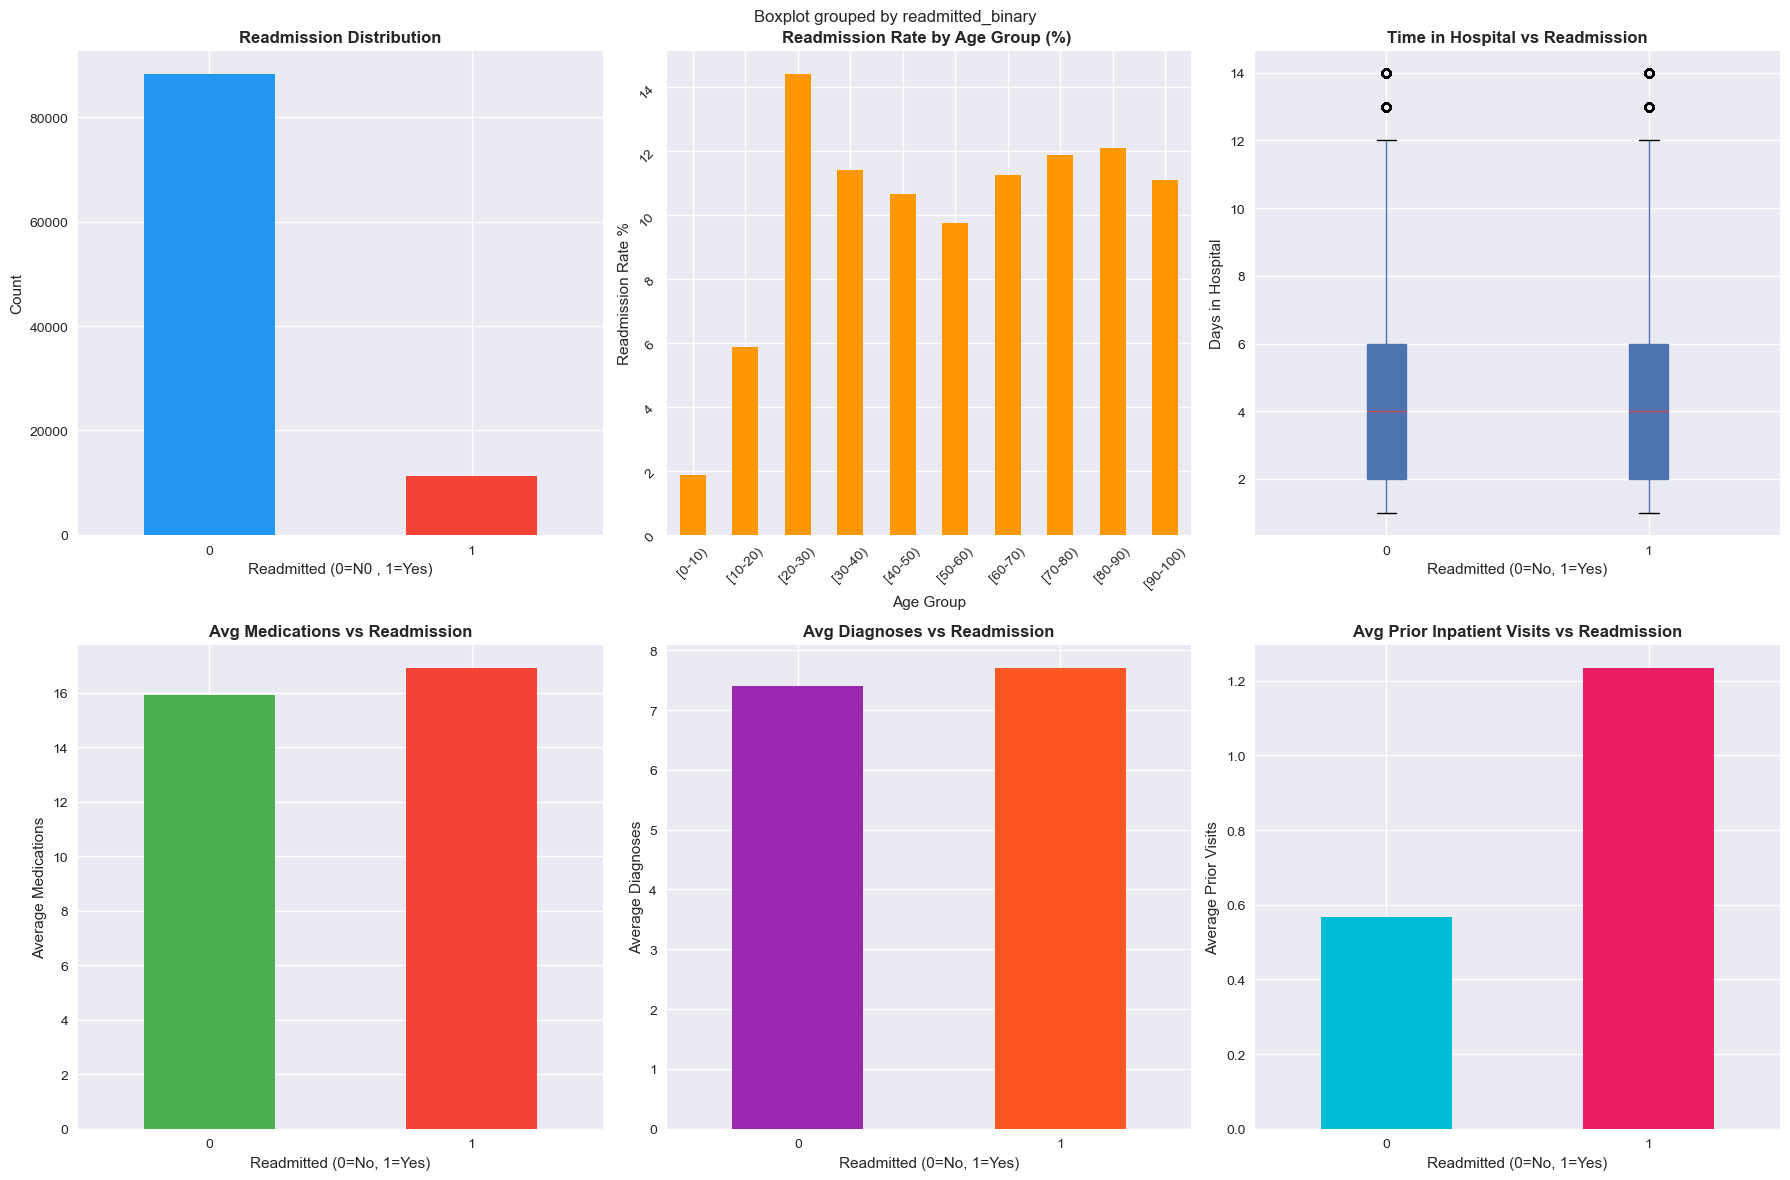

Charts saved!


In [7]:
# Set style for all charts
plt.style.use("seaborn-v0_8")
fig, axes = plt.subplots(2,3, figsize=(18,12))
fig.suptitle("Pakistan Hospital Readmission Analysis\nExploratory Data Analysis",fontsize=16, fontweight="bold", y=1.02)

# Chart 1 - Readmission Distribution
ax1 = axes[0,0]
colors = ["#2196F3", "#F44336"]
df_clean["readmitted_binary"].value_counts().plot(kind="bar", ax=ax1, color=colors)
ax1.set_title("Readmission Distribution", fontweight="bold")
ax1.set_xlabel("Readmitted (0=N0 , 1=Yes)")
ax1.set_ylabel("Count")
ax1.tick_params(rotation=0)

# Chart 2 - Readmission by Age
ax2 = axes[0,1]
age_readmission = df_clean.groupby("age")["readmitted_binary"].mean()*100
age_readmission.plot(kind="bar", ax=ax2, color="#FF9800")
ax2.set_title("Readmission Rate by Age Group (%) ", fontweight="bold")
ax2.set_xlabel("Age Group")
ax2.set_ylabel("Readmission Rate %")
ax2.tick_params(rotation=45)

# Chart 3 - Time in Hospital vs Readmission
ax3 = axes[0,2]
df_clean.boxplot(column="time_in_hospital", by="readmitted_binary", ax=ax3, patch_artist=True)
ax3.set_title("Time in Hospital vs Readmission", fontweight="bold" )
ax3.set_xlabel("Readmitted (0=No, 1=Yes)")
ax3.set_ylabel("Days in Hospital")

# Chart 4 - Number of Medications vs Readmission
ax4 = axes[1,0]
df_clean.groupby("readmitted_binary")["num_medications"].mean().plot(kind="bar", ax=ax4, color=["#4CAF50", "#F44336"])
ax4.set_title("Avg Medications vs Readmission", fontweight="bold")
ax4.set_xlabel("Readmitted (0=No, 1=Yes)")
ax4.set_ylabel("Average Medications")
ax4.tick_params(rotation=0)

# Chart 5 - Number of Diagnoses vs Readmission
ax5 = axes[1,1]
df_clean.groupby("readmitted_binary")["number_diagnoses"].mean().plot(kind="bar", ax=ax5, color=["#9C27B0", "#FF5722"])
ax5.set_title("Avg Diagnoses vs Readmission", fontweight="bold")
ax5.set_xlabel("Readmitted (0=No, 1=Yes)")
ax5.set_ylabel("Average Diagnoses")
ax5.tick_params(rotation=0)

# Chart 6 - Prior Inpatient Visits vs Readmission
ax6 = axes[1,2]
df_clean.groupby("readmitted_binary")["number_inpatient"].mean().plot(kind="bar", ax=ax6, color=["#00BCD4", "#E91E63"])
ax6.set_title("Avg Prior Inpatient Visits vs Readmission", fontweight="bold")
ax6.set_xlabel("Readmitted (0=No, 1=Yes)")
ax6.set_ylabel("Average Prior Visits")
ax6.tick_params(rotation=0)

plt.tight_layout()
plt.savefig("../static/eda_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Charts saved!")



In [8]:
from sklearn.preprocessing import LabelEncoder

df_model = df_clean.copy()

# Encode categorical columns
cat_cols = ['race', 'gender', 'age', 'admission_type_id',
            'discharge_disposition_id', 'admission_source_id',
            'medical_specialty', 'diag_1', 'diag_2', 'diag_3',
            'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide',
            'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
            'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
            'tolazamide', 'examide', 'citoglipton', 'insulin',
            'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone',
            'metformin-pioglitazone', 'change', 'diabetesMed']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("Feature Engineering Complete!")
print("Dataset shape:", df_model.shape)
print("\nAll columns are now numeric:")
print("df_model.dtypes.value_counts()")

Feature Engineering Complete!
Dataset shape: (99493, 46)

All columns are now numeric:
df_model.dtypes.value_counts()


In [9]:
# Save cleaned and encoded dataset to CSV
df_model.to_csv("../data/cleaned_data.csv", index=False)

# Save cleaned and encoded dataset to CSV
df_clean.to_csv('../data/clean_data_readable.csv', index=False)

print("Files saved successfully!")
print("cleaned_data.csv → for ML model training")
print("clean_data_readable.csv → for visualizations and dashboard")

Files saved successfully!
cleaned_data.csv → for ML model training
clean_data_readable.csv → for visualizations and dashboard


In [10]:
print("=" * 50)
print("DAY 1 COMPLETE!")
print("=" * 50)
print(f"Total patients loaded: 101,766")
print(f"Patients after cleaning: 99,493")
print(f"Total features: 46")
print(f"Readmission rate: 11.16%")
print(f"High risk patients: 11,357")
print(f"Low risk patients: 88,136")
print("=" * 50)
print("Files created:")
print(" data/cleaned_data.csv")
print(" data/clean_data_readable.csv")
print(" static/eda_charts.png")
print("=" * 50)
print("Tomorrow - Day 2: MySQL Database Setup!")
print("=" * 50)

DAY 1 COMPLETE!
Total patients loaded: 101,766
Patients after cleaning: 99,493
Total features: 46
Readmission rate: 11.16%
High risk patients: 11,357
Low risk patients: 88,136
Files created:
 data/cleaned_data.csv
 data/clean_data_readable.csv
 static/eda_charts.png
Tomorrow - Day 2: MySQL Database Setup!
